# Pitch Estimation with Self-Supervised Equivariant Learning 

Equivariant SSL is an exciting area of research within the field of MIR and has been applied succsesfully to a growing number of tasks in MIR. Such as tempo, pitch and key estimation. This notebook walks through a simplified implementation of PESTO, a self-supervised model for pitch estimation.

### Key Concept
The key idea presented by this approach is rather than labelling audio with pitch values and using a supervised learning model, we pursue a self-supervised approach by exploiting a physical property of the Constant-Q Transform (CQT): **a pitch shift in audio corresponds to a translation in CQT bins**. 

We train a model to be *equivariant* to this translation, meaning its output shifts predictably when the input shifts. From this the model is able to learn to predict relative pitch. Absolute pitch labels can then be easily recovered thereafter.

### Notebook structure
1. Imports & config
2. Feature extraction (CQT)
3. Data loading
4. Model
5. Losses
6. Training
7. Inference & visualisation
8. Embedding visualisation

We encourage you to check out the original implementation from which this notebook is based: [PESTO](https://github.com/SonyCSLParis/pesto-full) and the original paper.

## 1. Imports & Config

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from tqdm import tqdm
from nnAudio.features.cqt import CQT

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
# HCQT parameters
HARMONICS         = [1]       # which harmonics to use (1 = standard CQT)
HOP_DURATION_MS   = 10.0      # hop size in milliseconds
FMIN              = 27.5      # lowest frequency (A0)
BINS_PER_SEMITONE = 3         # frequency resolution
N_BINS            = 88 * BINS_PER_SEMITONE  # 264 total CQT bins (88 semitones * 3)
CENTER_BINS       = True

# Training
BATCH_SIZE  = 256
NUM_EPOCHS  = 10
LR          = 1e-4

# Loss weights
W_EQUIV = 1.0   # ShiftCrossEntropy  (equivariance : distribution shift)
W_FREQ  = 1.0   # PowerSeries        (equivariance : frequency ratio)
W_INV   = 1.0   # CrossEntropy       (invariance   : augmentation)

# Pitch shift range (in CQT bins, ± semitones * bins_per_semitone)
MAX_SHIFT = BINS_PER_SEMITONE * 11 // 2   # ~16 bins
MIN_SHIFT = -MAX_SHIFT

# Paths
DATA_DIR   = "data/vocadito"
CACHE_PATH = "cache/hcqt_train_vocadito.pt"
TRAIN_CSV  = "train_files_vocadito.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


## 2. Feature Extraction

### Why the CQT?

The Constant-Q Transform uses a logarithmic frequency axis, which means equal musical intervals (e.g. one semitone) correspond to equal distances in bins, regardless of which octave you're in. This is what gives us the property we need: **a pitch shift in audio = a translation in CQT bins**.

In [3]:
class CQTModule(nn.Module):
    """Simplified CQT module for a single harmonic."""
    def __init__(self, sr, hop_length, fmin, bins_per_semitone, n_bins, center_bins):
        super().__init__()
        
        # Adjust fmin if center_bins is True so centers land on semitone boundaries
        if center_bins:
            fmin = fmin / 2 ** ((bins_per_semitone - 1) / (24 * bins_per_semitone))

        # Standard CQT kernel from nnAudio
        self.cqt_kernel = CQT(
            sr=sr, 
            hop_length=hop_length, 
            fmin=fmin, 
            n_bins=n_bins,
            bins_per_octave=12 * bins_per_semitone, 
            output_format="Complex", 
            verbose=False
        )

    def forward(self, audio):
        # Result shape: (batch, freq_bins, time, 2)
        return self.cqt_kernel(audio)

class ToLogMagnitude(nn.Module):
    """Converts complex CQT to log-magnitude in dB.
    
    Input:  (N, 1, freq_bins) complex
    Output: (N, 1, freq_bins) float
    """
    def __init__(self):
        super().__init__()
        self.eps = torch.finfo(torch.float32).eps

    def forward(self, x):
        # x is already complex (N, 1, freq_bins)
        if x.is_complex():
            x = x.abs()
        return x.clamp(min=self.eps).log10().mul(20)

## 3. Data Loading

We use a selection of stems from the MDB-stem-synth dataset.

The cell below will:
- **If a cache file exists**: load the pre-computed HCQTs directly (fast)
- **If not**: compute HCQTs from the audio files and save to cache

When distributing this notebook, a pre-computed cache file will be provided so you can skip the computation step :).

In [4]:
# have a look at the data

example_audio_path = DATA_DIR + "/Audio/vocadito_2.wav"

waveform, sr = torchaudio.load(example_audio_path)
print(f"Loaded audio: {example_audio_path}")
print(f"Waveform shape: {waveform.shape}, Sample rate: {sr}")

Loaded audio: data/vocadito/Audio/vocadito_2.wav
Waveform shape: torch.Size([1, 1552673]), Sample rate: 44100


In [5]:
# load the list of training files from the CSV file
with open(TRAIN_CSV, "r") as f:
    TRAIN_FILES = [line.strip() for line in f if line.strip()]

print(f"Loaded {len(TRAIN_FILES)} training files from {TRAIN_CSV}")
print(TRAIN_FILES[:5])  # print the first 5 file paths to verify

Loaded 40 training files from train_files_vocadito.csv
['Audio/vocadito_31.wav', 'Audio/vocadito_18.wav', 'Audio/vocadito_8.wav', 'Audio/vocadito_33.wav', 'Audio/vocadito_11.wav']


In [6]:
def compute_cqt_dataset(file_list, data_dir, hop_duration_ms=10.0):
    """Load audio files, compute CQT for each, and concatenate into a single tensor.
    Returns:
        frames: (N, 1, freq_bins) complex tensor, one row per time frame
    """
    all_frames = []
    cqt_module = None
    current_sr = None
    for fname in tqdm(file_list, desc="Computing CQTs"):
        path = os.path.join(data_dir, fname)
        if not os.path.exists(path):
            print(f"  Skipping (not found): {fname}")
            continue
        waveform, sr = torchaudio.load(path)
        audio_mono = waveform.mean(dim=0)
        if sr != current_sr:
            current_sr = sr
            hop_length = int(hop_duration_ms * sr / 1000 + 0.5)
            cqt_module = CQTModule(
                sr=sr, hop_length=hop_length,
                fmin=FMIN, bins_per_semitone=BINS_PER_SEMITONE,
                n_bins=N_BINS, center_bins=CENTER_BINS
            )
        with torch.no_grad():
            cqt = cqt_module(audio_mono)                           # (1, freq_bins, time, 2)
            cqt = cqt.squeeze(0)                                   # (freq_bins, time, 2)
            cqt = cqt.permute(1, 0, 2)                            # (time, freq_bins, 2)
            cqt = torch.view_as_complex(cqt.contiguous().float())  # (time, freq_bins) complex
            cqt = cqt.unsqueeze(1)                                 # (time, 1, freq_bins)
        all_frames.append(cqt)
    return torch.cat(all_frames, dim=0)


# Load or compute
# To download the pre-computed cache (when available):
#   import urllib.request
#   urllib.request.urlretrieve("<CACHE_URL>", CACHE_PATH)

if os.path.exists(CACHE_PATH):
    print("Loading pre-computed CQT from cache...")
    frames = torch.load(CACHE_PATH)
else:
    print("Cache not found — computing CQTs from audio files...")
    frames = compute_cqt_dataset(TRAIN_FILES, DATA_DIR, HOP_DURATION_MS)
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    torch.save(frames, CACHE_PATH)
    print(f"Saved cache to {CACHE_PATH}")

print(f"Dataset: {len(frames):,} frames  |  shape: {frames.shape}")

# Apply log magnitude and build dataloader
log_magnitude = ToLogMagnitude()
frames_log = log_magnitude(frames)                      # (N, harmonics, freq_bins)
dataset    = torch.utils.data.TensorDataset(frames_log)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Loading pre-computed CQT from cache...
Dataset: 81,734 frames  |  shape: torch.Size([81734, 1, 264])


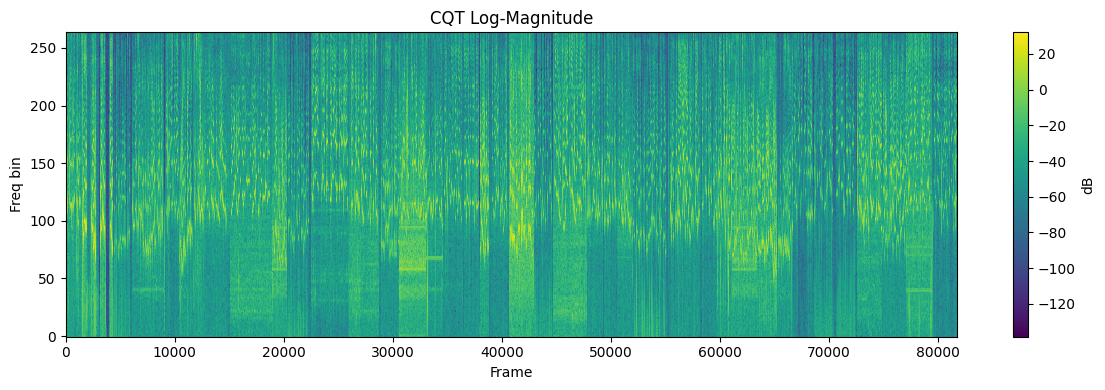

In [7]:
import matplotlib.pyplot as plt

# Grab a slice of 300 frames (~3s at 10ms hop) and squeeze the harmonics dim
n_frames = 100000
spec = frames_log[:n_frames, 0, :].numpy()  # (300, freq_bins)

plt.figure(figsize=(12, 4))
plt.imshow(spec.T, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar(label="dB")
plt.xlabel("Frame")
plt.ylabel("Freq bin")
plt.title("CQT Log-Magnitude")
plt.tight_layout()
plt.show()

## 4. Model

The encoder is a 1D CNN that takes a single CQT frame (freq_bins,) and outputs a probability distribution over pitch bins.

A few architectural choices worth noting:

- **LayerNorm over frequency and channels**: normalises each frame independently, so the model is invariant to overall loudness
- **1D convolutions along the log-frequency axis**: 
- **ToeplitzLinear as the final layer**: 

In [8]:
class ToeplitzLinear(nn.Conv1d):
    """A weight-tied linear layer implemented as a 1D convolution.
    
    Using the same weights for every position enforces that the mapping from
    freq bins to output bins is shift-equivariant by construction, shifting
    the input by n bins shifts the output by n bins.
    """
    def __init__(self, in_features, out_features):
        super().__init__(in_channels=1, out_channels=1,
                         kernel_size=in_features + out_features - 1,
                         padding=out_features - 1, bias=False)

    def forward(self, x):
        return super().forward(x.unsqueeze(-2)).squeeze(-2)


class PESTOEncoder(nn.Module):
    """Simplified 1D ResNet encoder for pitch estimation.
    
    Input:  (batch, harmonics, freq_bins)
    Output: (batch, output_dim) softmax probability over pitch bins
    """
    def __init__(self,
                 n_harmonics=1,
                 n_bins_in=264,
                 output_dim=384,        # 128 * bins_per_semitone
                 channels=(32, 16, 8),  # hidden channel sizes
                 kernel_size=15,
                 dropout=0.2):
        super().__init__()
        self.hparams = dict(n_harmonics=n_harmonics, n_bins_in=n_bins_in,
                            output_dim=output_dim, channels=channels,
                            kernel_size=kernel_size, dropout=dropout)

        pad = kernel_size // 2
        act = partial(nn.LeakyReLU, negative_slope=0.3)

        # Normalise over frequency + channel dims (not time, so variable-length input works)
        self.norm = nn.LayerNorm([n_harmonics, n_bins_in])

        # Prefiltering: learn local spectral shapes
        self.prefilter = nn.Sequential(
            nn.Conv1d(n_harmonics, channels[0], kernel_size, padding=pad),
            act(), nn.Dropout(dropout),
            nn.Conv1d(channels[0], channels[0], kernel_size, padding=pad),
            act(), nn.Dropout(dropout),
        )

        # Pointwise layers: mix channel information
        self.pointwise = nn.Sequential(
            nn.Conv1d(channels[0], channels[1], 1), act(), nn.Dropout(dropout),
            nn.Conv1d(channels[1], channels[2], 1), act(), nn.Dropout(dropout),
            nn.Conv1d(channels[2], 1,           1), act(), nn.Dropout(dropout),
        )

        self.flatten  = nn.Flatten(start_dim=1)
        self.fc       = ToeplitzLinear(n_bins_in, output_dim)
        self.softmax  = nn.Softmax(dim=-1)

    def forward(self, x):
        x = self.norm(x)
        x = self.prefilter(x)
        x = self.pointwise(x)
        x = self.flatten(x)
        return self.softmax(self.fc(x))


OUTPUT_DIM = 128 * BINS_PER_SEMITONE

# encoder = PESTOEncoder(
#     n_harmonics=len(HARMONICS),
#     n_bins_in= 232, #N_BINS,
#     output_dim=OUTPUT_DIM,
# ).to(DEVICE)


# The CQT is cropped by PitchShiftCQT before entering the encoder,
# so n_bins_in must match the cropped size, not the full CQT size
N_BINS_CROPPED = N_BINS - MAX_SHIFT + MIN_SHIFT  # 264 - 16 - 16 = 232

encoder = PESTOEncoder(
    n_harmonics=len(HARMONICS),
    n_bins_in=N_BINS_CROPPED,       # <-- was N_BINS, now the cropped size
    output_dim=OUTPUT_DIM,
).to(DEVICE)


n_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f"Encoder parameters: {n_params:,}")

Encoder parameters: 17,656


## 5. Losses

PESTO uses three losses, each enforcing a different property.

### Pitch-shift augmentation

Before computing any loss we need pairs of frames. `PitchShiftCQT` takes a batch of CQT frames and returns:
- `x`: the original crop
- `x_shifted`: the same frames but shifted by a random `n` bins
- `n_steps`: the shift amount for each item in the batch

The shift is implemented by cropping, we compute the full CQT and then take two different sub-windows along the frequency axis.

In [9]:
class PitchShiftCQT(nn.Module):
    """Simulates pitch shifting by cropping different frequency windows from the CQT.
    
    For a batch of CQT frames, returns two crops separated by a random bin offset,
    along with the offset itself. No audio resampling needed.
    """
    def __init__(self, min_steps, max_steps):
        super().__init__()
        self.min_steps = min_steps
        self.max_steps = max_steps
        self.lower_bin = max_steps   # start of the crop window

    def forward(self, x):
        batch_size, _, input_height = x.size()
        output_height = input_height - self.max_steps + self.min_steps

        n_steps = torch.randint(self.min_steps, self.max_steps + 1,
                                (batch_size,), device=x.device)

        x_orig   = x[..., self.lower_bin: self.lower_bin + output_height]
        x_shifted = self._crop(x, self.lower_bin - n_steps, output_height)
        return x_orig, x_shifted, n_steps

    def _crop(self, x, first_bin, length):
        """Extract a sub-window of `length` bins starting at `first_bin` for each item."""
        idx = first_bin.unsqueeze(-1) + torch.arange(length, device=x.device)
        idx = idx.view(x.size(0), 1, length).expand(x.size(0), x.size(1), length)
        return x.gather(-1, idx)


pitch_shift = PitchShiftCQT(min_steps=MIN_SHIFT, max_steps=MAX_SHIFT).to(DEVICE)

Lets have a look at what a original and pitch shifted data looks like.

Original shape: torch.Size([256, 1, 264])
Shifted shape:  torch.Size([256, 1, 232])


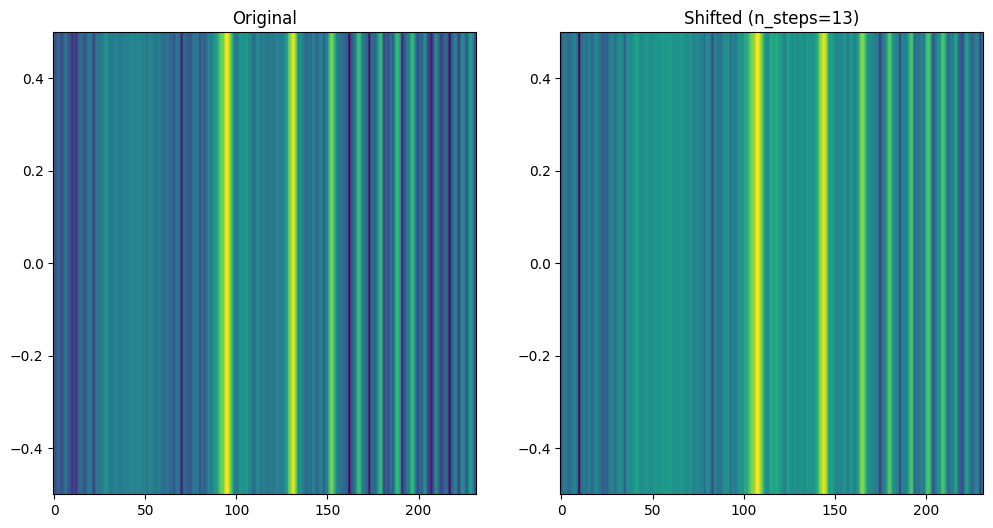

In [10]:
# load a batch of data and test the pitch shift
for batch in dataloader:
    x = batch[0].to(DEVICE)  # (batch, harmonics, freq_bins)
    x_orig, x_shifted, n_steps = pitch_shift(x)
    print(f"Original shape: {x.shape}")
    print(f"Shifted shape:  {x_shifted.shape}")
    break
    # print(f"Bin offsets:    {n_steps}")
    # break

# visulise the original and shifted spectrograms looks like for the first item in the batch
def plot_spectrograms(x_orig, x_shifted, n_steps):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(x_orig[0].cpu(), aspect='auto', origin='lower')
    axes[0].set_title("Original")
    axes[1].imshow(x_shifted[0].cpu(), aspect='auto', origin='lower')
    axes[1].set_title(f"Shifted (n_steps={n_steps[0].item()})")
    plt.show()

plot_spectrograms(x_orig, x_shifted, n_steps)


### Loss 1: ShiftCrossEntropy

This is the primary equivariance loss. The encoder outputs a probability distribution over pitch bins. If we shift the input CQT by `n` bins, the output distribution should slide along by `n` positions.

We enforce this by padding both distributions and computing cross entropy after aligning them by the known shift `n`. No labels required! Only the relative shift between the two frames.

In [11]:
class ShiftCrossEntropy(nn.Module):
    """Equivariance loss: the output distribution should translate by n bins
    when the input CQT is shifted by n bins.
    """
    def __init__(self, pad_length):
        super().__init__()
        self.pad_length = pad_length
        self.ce = nn.CrossEntropyLoss()

    def forward(self, y, y_shifted, n_steps):
        # Pad both distributions to make room for the shift
        y        = F.pad(y,        (self.pad_length, self.pad_length))
        y_shifted = F.pad(y_shifted, (2 * self.pad_length, 2 * self.pad_length))

        # Align y_shifted to y by extracting the window at position n_steps
        idx = n_steps.unsqueeze(1) + torch.arange(y.size(-1), device=n_steps.device) + self.pad_length
        y_shifted_aligned = y_shifted.gather(1, idx)

        # Symmetric: enforce both directions
        return (self.ce(y, y_shifted_aligned.detach()) +
                self.ce(y_shifted_aligned, y.detach())) / 2


sce_loss = ShiftCrossEntropy(pad_length=MAX_SHIFT).to(DEVICE)

### Loss 2: PowerSeries

ShiftCrossEntropy treats the output bins as evenly-spaced integers. This loss operates in frequency space instead.

It projects the output distribution down to a single scalar using a geometric weighting, effectively a weighted frequency estimate.

In [12]:
# class HuberLoss(nn.Module):
#     def __init__(self, tau: float):
#         super(HuberLoss, self).__init__()
#         self.register_buffer("tau", torch.tensor(tau), persistent=False)

#     def forward(self, x):
#         x = x.abs()
#         return torch.where(x.le(self.tau),
#                            x ** 2 / 2,
#                            self.tau ** 2 / 2 + self.tau * (x - self.tau))


# class PowerSeries(nn.Module):
#     def __init__(self, value: float, power_min, power_max, tau: float = 1.):
#         super(PowerSeries, self).__init__()
#         self.value = value

#         # compute weights vector
#         powers = torch.arange(power_min, power_max)
#         self.register_buffer("weights", self.value ** powers, persistent=False)

#         self.dim = len(self.weights)
#         self.loss_fn = HuberLoss(tau)

#     def forward(self, x1: torch.Tensor, x2: torch.Tensor, target: torch.Tensor,
#                 nlog_c1: torch.Tensor | None = None, nlog_c2: torch.Tensor | None = None) -> Dict[str, torch.Tensor]:
#         r"""x2[i] is the pitch-shifted version of x1[i] by target[i] semitones, i.e.
#             if x1[i] is a C# and x2[i] is a C then target[i] = -1

#         """
#         z1 = self.project(x1)
#         z2 = self.project(x2)
#         if nlog_c1 is not None:
#             z1 = z1 * torch.exp(-nlog_c1)
#         if nlog_c2 is not None:
#             z2 = z2 * torch.exp(-nlog_c2)

#         # compute frequency ratios out of semitones
#         freq_ratios = self.value ** target.float()

#         # compute equivariant loss
#         loss_12 = self.loss_fn(z2 / z1 - freq_ratios).mean()
#         loss_21 = self.loss_fn(z1 / z2 - 1/freq_ratios).mean()

#         return (loss_12 + loss_21) / 2

#     def project(self, x: torch.Tensor):
#         r"""Projects a batch of vectors into a batch of scalars
#         Args:
#             x (torch.Tensor): batch of input vectors, shape (batch_size, output_dim)

#         Returns:
#             torch.Tensor: batch of output scalars, shape (batch_size)
#         """
#         return x.mv(self.weights)

#TODO finish simplification

class PowerSeries(nn.Module):
    """Equivariance loss: a scalar projection of the output should scale
    by the correct frequency ratio when the input is pitch-shifted.
    """
    def __init__(self, base=2 ** (1/36), output_dim=384, tau=2 ** (1/6) - 1):
        super().__init__()
        # Geometric weights: base^0, base^1, ..., base^(output_dim-1)
        weights = base ** torch.arange(-output_dim + 1, 1)
        self.register_buffer("weights", weights)
        self.base = base
        self.tau  = tau

    def forward(self, y, y_shifted, n_steps):
        z        = y.mv(self.weights)          # scalar per frame
        z_shifted = y_shifted.mv(self.weights)

        # Expected ratio between z_shifted and z
        freq_ratio = self.base ** n_steps.float()

        # Huber loss on the ratio (robust to outliers)
        loss_fwd = self._huber(z_shifted / z         - freq_ratio).mean()
        loss_bwd = self._huber(z         / z_shifted - 1 / freq_ratio).mean()
        return (loss_fwd + loss_bwd) / 2

    def _huber(self, x):
        x = x.abs()
        return torch.where(x <= self.tau,
                           x ** 2 / 2,
                           self.tau ** 2 / 2 + self.tau * (x - self.tau))


power_loss = PowerSeries(output_dim=OUTPUT_DIM).to(DEVICE)

### Loss 3: Invariance loss

The two equivariance losses train the model on pairs of pitch-shifted frames. But a model could satisfy them while still being sensitive to irrelevant variation like recording noise or volume changes, aspects that shouldn't affect the pitch estimate.

The invariance loss addresses this. We take the original frame and an acoustically augmented version (random noise, random gain) and enforce that the outputs are identical. This is the standard self-supervised learning approach similar to SimCLR or BYOL.

The augmentations are applied inline in the training loop below so they are easy to see and modify.

In [13]:
def augment(x, min_snr=0.1, max_snr=2.0, min_gain=0.5, max_gain=1.5, p=0.7):
    """Apply random noise and gain to a batch of CQT frames.
    Each augmentation is applied independently with probability p.
    """
    B = x.size(0)

    # Random gain
    gain = x.new_empty(B).uniform_(min_gain, max_gain)
    gain[torch.rand(B) > p] = 1.0   # no-op for (1-p) fraction
    x = x * gain.view(B, 1, 1)

    # Random noise
    snr = x.new_empty(B).uniform_(min_snr, max_snr)
    snr[torch.rand(B) > p] = 0.0    # no-op for (1-p) fraction
    noise_std = snr * x.view(B, -1).std(dim=-1)
    x = x + noise_std.view(B, 1, 1) * torch.randn_like(x)

    return x


inv_loss_fn = nn.CrossEntropyLoss()

## 6. Training

The training loop puts all we have seen together! For each batch:

1. **Pitch-shift**: crop two frequency windows of CQT frames separated by a random offset `n`
2. **Augment**: apply noise and gain to one view for the invariance loss
3. **Forward**: pass all views through the encoder
4. **Losses**: compute all three losses and combine with fixed weights
5. **Update**: backward pass of gradient

In [14]:
optimizer = torch.optim.Adam(encoder.parameters(), lr=LR)

for epoch in range(NUM_EPOCHS):
    encoder.train()
    epoch_loss = 0.0

    for (x,) in tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
        x = x.to(DEVICE)

        # 1. Pitch-shift augmentation : crop two frequency windows
        x_orig, x_shifted, n_steps = pitch_shift(x)

        # 2. Acoustic augmentation : noise + gain on one view
        x_aug = augment(x_orig.clone())

        # 3. Forward passes
        y       = encoder(x_orig)     # original view
        y_shift = encoder(x_shifted)  # pitch-shifted view
        y_aug   = encoder(x_aug)      # acoustically augmented view

        # 4. Losses
        l_equiv = sce_loss(y, y_shift, n_steps)       # distribution should translate
        l_freq  = power_loss(y, y_shift, n_steps)     # scalar should scale by freq ratio
        l_inv   = (inv_loss_fn(y, y_aug.detach()) +
                   inv_loss_fn(y_aug, y.detach())) / 2 # output should be noise-invariant

        loss = W_EQUIV * l_equiv + W_FREQ * l_freq + W_INV * l_inv

        # 5. Update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1:2d} | loss: {epoch_loss / len(dataloader):.4f} "
          f"(equiv: {l_equiv.item():.4f}, freq: {l_freq.item():.4f}, inv: {l_inv.item():.4f})")

# Save checkpoint
torch.save({"state_dict": encoder.state_dict(), "hparams": encoder.hparams},
           "pesto_simplified.pt")
print("Checkpoint saved to pesto_simplified.pt")

Epoch  1 | loss: 11.9670 (equiv: 5.9586, freq: 0.0131, inv: 5.8822)


Epoch  2 | loss: 11.7373 (equiv: 5.8497, freq: 0.0133, inv: 5.7746)


Epoch  3 | loss: 11.3007 (equiv: 5.3151, freq: 0.0068, inv: 5.3699)


Epoch  4 | loss: 10.7964 (equiv: 5.2886, freq: 0.0067, inv: 5.3314)


Epoch  5 | loss: 10.7332 (equiv: 5.3232, freq: 0.0026, inv: 5.4083)


Epoch  6 | loss: 10.7132 (equiv: 5.4234, freq: 0.0226, inv: 5.4734)


Epoch  7 | loss: 10.7020 (equiv: 5.2269, freq: 0.0025, inv: 5.4074)


Epoch  8 | loss: 10.6951 (equiv: 5.3063, freq: 0.0131, inv: 5.3425)


Epoch  9 | loss: 10.6880 (equiv: 5.2025, freq: 0.0027, inv: 5.2797)


Epoch 10 | loss: 10.6852 (equiv: 5.3018, freq: 0.0271, inv: 5.4269)
Checkpoint saved to pesto_simplified.pt


## 7. Inference & Visualisation

After training, we need to recover **absolute** pitch. The model has learned a relative representation, it knows that A is one semitone above G# but the output bins have no fixed correspondence to MIDI values yet.

### estimate_shift!
We generate a handful of synthetic notes at known MIDI pitches, run them through the model, and measure the constant offset between predictions and ground truth. This offset is subtracted at inference time.

In [15]:
def reduce_activations(activations, reduction="alwa"):
    """Convert a probability distribution over bins to a single pitch value.
    
    alwa = argmax-local weighted averaging (from CREPE): finds the peak bin
    then refines with a weighted average in a local window.
    """
    device = activations.device
    num_bins = activations.size(1)
    bps = num_bins // 128
    all_pitches = torch.arange(num_bins, dtype=torch.float, device=device) / bps

    if reduction == "argmax":
        return activations.argmax(dim=1).float() / bps

    if reduction == "alwa":
        center = activations.argmax(dim=1, keepdim=True)
        window = torch.arange(1, 2 * bps, device=device) - bps
        idx    = (window + center).clip(0, num_bins - 1)
        crop_a = activations.gather(1, idx)
        crop_p = all_pitches.unsqueeze(0).expand_as(activations).gather(1, idx)
        return (crop_a * crop_p).sum(1) / crop_a.sum(1)

    raise ValueError(f"Unknown reduction: {reduction}")


def generate_synth_note(midi_pitch, sr=16000, duration=2, n_harmonics=5):
    """Generate a simple harmonic tone at a given MIDI pitch."""
    f0 = 440 * 2 ** ((midi_pitch - 69) / 12)
    t  = torch.arange(0, duration, 1 / sr)
    harmonics = torch.stack([torch.cos(2 * torch.pi * k * f0 * t) for k in range(1, n_harmonics + 1)], dim=1)
    return harmonics.mean(dim=1)


@torch.no_grad()
def estimate_shift(encoder, sr=16000):
    """Calibrate absolute pitch by comparing predictions on synthetic notes to known MIDI values."""
    encoder.eval()
    labels = torch.arange(60, 72)   # one octave of synthetic notes

    hop_length  = int(HOP_DURATION_MS * sr / 1000 + 0.5)
    hcqt_module = HarmonicCQT(harmonics=HARMONICS, sr=sr, hop_length=hop_length,
                               fmin=FMIN, bins_per_semitone=BINS_PER_SEMITONE,
                               n_bins=N_BINS, center_bins=CENTER_BINS)

    batch = []
    for p in labels:
        audio = generate_synth_note(p.item(), sr=sr)
        hcqt  = hcqt_module(audio)
        hcqt  = hcqt.squeeze(0).permute(2, 0, 1, 3)
        hcqt  = torch.view_as_complex(hcqt.float())
        # batch.append(log_magnitude(hcqt[0]))
        batch.append(log_magnitude(hcqt[0]).squeeze(0))  # remove the extra dim added by log_magnitude

    x = torch.stack(batch).to(DEVICE)
    x_crop, _, _ = pitch_shift(x)
    preds = reduce_activations(encoder(x_crop))

    shift = (preds - labels.float().to(DEVICE)).median()
    print(f"Estimated shift: {shift.item():.3f} MIDI semitones")
    return shift


shift = estimate_shift(encoder)

NameError: name 'HarmonicCQT' is not defined

In [ ]:
@torch.no_grad()
def run_inference(encoder, audio_path, shift):
    """Run pitch estimation on an audio file. Returns (times, pitches, hcqt_display)."""
    encoder.eval()

    waveform, sr = torchaudio.load(audio_path)
    audio_mono   = waveform.mean(dim=0)

    hop_length  = int(HOP_DURATION_MS * sr / 1000 + 0.5)
    hcqt_module = HarmonicCQT(harmonics=HARMONICS, sr=sr, hop_length=hop_length,
                               fmin=FMIN, bins_per_semitone=BINS_PER_SEMITONE,
                               n_bins=N_BINS, center_bins=CENTER_BINS)

    hcqt = hcqt_module(audio_mono).squeeze(0).permute(2, 0, 1, 3)
    hcqt = torch.view_as_complex(hcqt.float())   # (T, harmonics, freq_bins)
    hcqt_log = log_magnitude(hcqt)               # (T, harmonics, freq_bins)

    all_preds = []
    for start in range(0, len(hcqt_log), BATCH_SIZE):
        batch = hcqt_log[start:start + BATCH_SIZE].to(DEVICE)
        x, _, _ = pitch_shift(batch)
        preds = reduce_activations(encoder(x)) - shift
        all_preds.append(preds.cpu())

    pitches = torch.cat(all_preds).numpy()
    times   = np.arange(len(pitches)) * hop_length / sr
    display = hcqt_log[:len(pitches), 0].squeeze().numpy()   # (T, freq_bins)

    return times, pitches, display


audio_path = "data/mdb_stem_synth/audio_stems/AClassicEducation_NightOwl_STEM_01.RESYN.wav"
times, pitches, hcqt_display = run_inference(encoder, audio_path, shift)

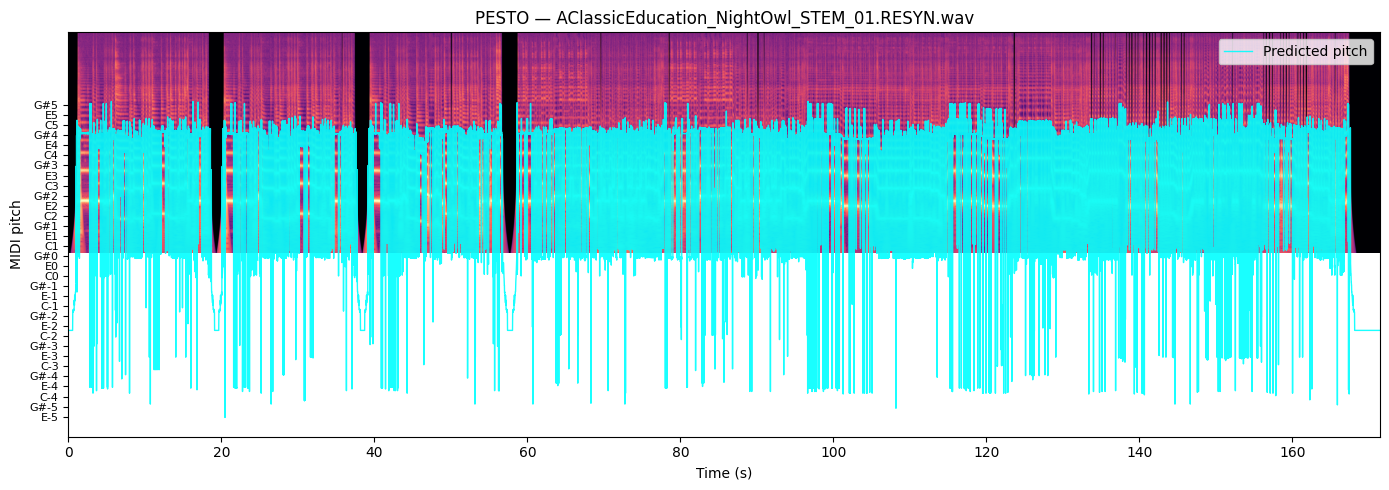

In [ ]:
# plot the CQT + predicted pitch overlay
midi_fmin  = 12 * np.log2(FMIN / 440) + 69
pitch_bins = (pitches - midi_fmin) * BINS_PER_SEMITONE

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(hcqt_display.T, aspect="auto", origin="lower", cmap="magma",
          extent=[times[0], times[-1], 0, hcqt_display.shape[1]])
ax.plot(times, pitch_bins, c="cyan", linewidth=1, alpha=0.9, label="Predicted pitch")
ax.set_xlabel("Time (s)")
ax.set_ylabel("MIDI pitch")
ax.set_title(f"PESTO — {audio_path.split('/')[-1]}")

notes     = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
midi_ticks = np.arange(int(pitches.min()), int(pitches.max()) + 1, 4)
ax.set_yticks((midi_ticks - midi_fmin) * BINS_PER_SEMITONE)
ax.set_yticklabels([f"{notes[int(m)%12]}{int(m)//12-1}" for m in midi_ticks], fontsize=8)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 8. Embedding Visualisation

We can inspect what the model has actually learned by visualising the pre-softmax embeddings in 2D.

A well-trained equivariant model should produce embeddings that are smoothly organised by pitch, nearby pitches should cluster together.

In [ ]:
# Extract pre-softmax embeddings via a forward hook
embeddings_list = []
hook = encoder.softmax.register_forward_hook(
    lambda m, inp, out: embeddings_list.append(inp[0].detach().cpu())
)

with torch.no_grad():
    hcqt_log_full = log_magnitude(torch.view_as_complex(
        hcqt_module(audio_mono.mean(dim=0) if audio_mono.ndim > 1 else audio_mono)
        .squeeze(0).permute(2, 0, 1, 3).float()
    ))
    for start in range(0, len(hcqt_log_full), BATCH_SIZE):
        batch = hcqt_log_full[start:start + BATCH_SIZE].to(DEVICE)
        x, _, _ = pitch_shift(batch)
        encoder(x)

hook.remove()
embeddings = torch.cat(embeddings_list).numpy()
print(f"Embeddings: {embeddings.shape}")

# Subsample for speed
MAX_PTS = 5000
if len(embeddings) > MAX_PTS:
    idx = np.sort(np.random.choice(len(embeddings), MAX_PTS, replace=False))
    embeddings_s = embeddings[idx]
    pitches_s    = pitches[idx]
else:
    embeddings_s, pitches_s = embeddings, pitches

# Dimensionality reduction
try:
    import umap
    reducer, method = umap.UMAP(n_components=2, random_state=42), "UMAP"
except ImportError:
    from sklearn.manifold import TSNE
    reducer, method = TSNE(n_components=2, random_state=42, perplexity=30), "t-SNE"

print(f"Running {method}...")
emb_2d = reducer.fit_transform(embeddings_s)

# Plot
notes = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=pitches_s, cmap="plasma", s=4, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label="MIDI pitch")
axes[0].set_title(f"{method} — coloured by pitch")

sc2 = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=pitches_s % 12, cmap="hsv",
                       vmin=0, vmax=12, s=4, alpha=0.7)
cbar = plt.colorbar(sc2, ax=axes[1], ticks=np.arange(0.5, 12))
cbar.ax.set_yticklabels(notes, fontsize=8)
axes[1].set_title(f"{method} — coloured by pitch class")

for ax in axes:
    ax.set_xlabel(f"{method} 1")
    ax.set_ylabel(f"{method} 2")

plt.suptitle("Learned encoder embeddings", fontsize=11)
plt.tight_layout()
plt.show()